In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [7]:
E1 = np.load("E1.npy")
E2 = np.load("E2.npy")
dist = np.load("dist.npy")
soc = np.load("gap.npy")
def read_path(name,steps,skips=[]):
    energy = []
    distance = []
    for i in range(steps):
        if i in skips:
            continue
        tem_name = f"{name}_step{i:04d}.npz"
        energy.append(np.load(tem_name)["energy"])
        distance.append(np.load(tem_name)["distance"])
    return  np.array(energy), np.array(distance)
d_e,d_d = read_path("D",32,skips=[0,1,2,14,18])
q_e,q_d = read_path("Q",32)



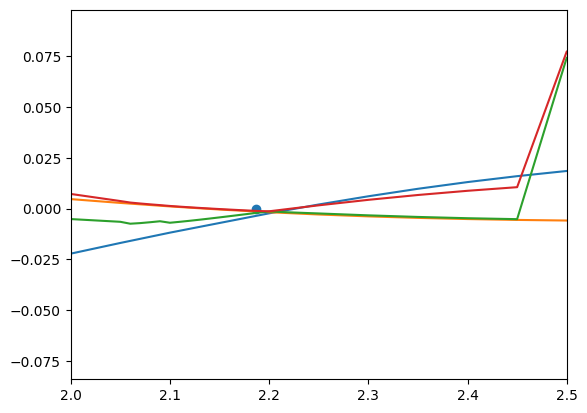

In [8]:
d_e -= -186.76
q_e -= -186.76
E1 -= -186.76
E2 -= -186.76
plt.plot(d_d,d_e,label="")
plt.plot(q_d,q_e)
plt.plot(dist,E1)
plt.plot(dist,E2)
plt.xlim(2,2.5)
plt.scatter(2.18656,0)

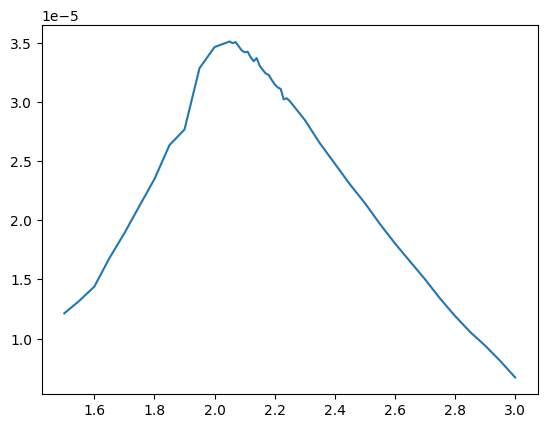

In [55]:
plt.plot(dist,soc)

In [43]:
from chemlab.util.file_system import qchem_out_force
tem = qchem_out_force()

tem.read_file(filename="soc_test.out",different_type="soc")

In [49]:
tem.force_e1

array([[-6.37834842e-09, -6.35012919e-09, -2.42367234e-07,
         2.27885799e-07,  2.03076401e-09,  2.51791485e-08],
       [-7.62211317e-09, -7.64878727e-09,  9.86794061e-07,
        -9.44865887e-07, -5.37701252e-09, -2.12802611e-08],
       [ 3.47137840e-09, -3.42148558e-09, -3.28053506e-10,
         2.91068417e-10, -8.97450253e-12, -3.93322716e-12]])

In [46]:
tem2 = qchem_out_force(
)
tem2.read_file("ana_test.out",different_type="analytical")

In [48]:
tem2.force.shape

(6, 3)